# Task 1 & 2: Interactive Exploratory Data Analysis & Visualizations
**Project:** Birhan Energies Pricing Analytics Framework  
**Data Scientist:** Soliana Hailekiros Weldegewergs  

This notebook interactive visualizes historical Brent Crude Oil prices, calculates rolling monthly metrics, tracks distribution profiles, and auto-saves artifacts cleanly into the `Visuals/` directory.

In [3]:
%load_ext autoreload
%autoreload 2

import os
import sys

# Append the project root directory to sys.path so the notebook can find the 'src' folder
project_root = os.path.abspath(os.path.join(".."))
if project_root not in sys.path:
    sys.path.append(project_root)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.data_pipeline import load_and_clean_data, apply_log_transformations, execute_adf_diagnostic

# Set presentation style metrics
sns.set_theme(style="whitegrid")

# Define and guarantee your visuals directory target structure
visuals_dir = os.path.join("Visuals")
os.makedirs(visuals_dir, exist_ok=True)
print(f"Workspace initialized. All generated plots will save dynamically to: {visuals_dir}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Workspace initialized. All generated plots will save dynamically to: Visuals


## 1. Load Data Through Ingestion Pipeline

In [4]:
data_path = os.path.join("..", "data", "raw", "BrentOilPrices.csv")
df = load_and_clean_data(data_path)
df = apply_log_transformations(df)

print("\n--- First 5 Cleaned Data Records ---")
display(df.head())

2026-07-12 00:48:44,656 - INFO - Ingesting raw data from: ..\data\raw\BrentOilPrices.csv
2026-07-12 00:48:44,674 - INFO - Parsing dates and verifying timeline structural order...
2026-07-12 00:48:45,117 - INFO - Data ingestion completed. Total clean trading records: 9011
2026-07-12 00:48:45,118 - INFO - Calculating continuous log return vectors and moving indicators...



--- First 5 Cleaned Data Records ---


,Date,Price,Log_Return,Rolling_Mean_21,Rolling_Std_21,Is_Outlier
0,1987-05-20,18.63,NaN,NaN,NaN,0
1,1987-05-21,18.45,-0.009709,NaN,NaN,0
2,1987-05-22,18.55,0.005405,NaN,NaN,0
3,1987-05-25,18.60,0.002692,NaN,NaN,0
4,1987-05-26,18.63,0.001612,NaN,NaN,0


## 2. Generate and Export Absolute Price & Moving Trends

Saved Figure 1 to: Visuals\brent_spot_price_trends.png


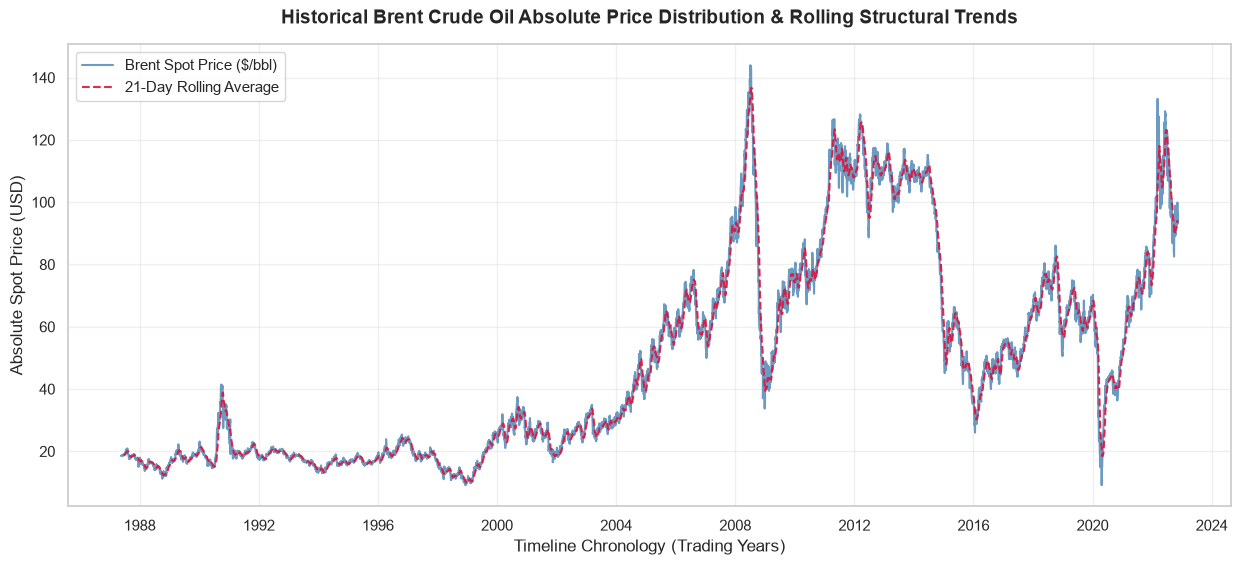

In [5]:
fig, ax1 = plt.subplots(figsize=(15, 6))

# Plot raw historical trend vs moving 21-day average envelope
ax1.plot(df['Date'], df['Price'], color='steelblue', alpha=0.8, label='Brent Spot Price ($/bbl)')
ax1.plot(df['Date'], df['Rolling_Mean_21'], color='crimson', linestyle='--', alpha=0.9, label='21-Day Rolling Average')
ax1.set_xlabel('Timeline Chronology (Trading Years)', fontsize=12)
ax1.set_ylabel('Absolute Spot Price (USD)', fontsize=12)
ax1.legend(loc='upper left', fontsize=11)

plt.title('Historical Brent Crude Oil Absolute Price Distribution & Rolling Structural Trends', fontsize=14, fontweight='bold', pad=15)
plt.grid(True, alpha=0.3)

# Auto-save into Visuals folder
fig1_path = os.path.join(visuals_dir, "brent_spot_price_trends.png")
plt.savefig(fig1_path, dpi=300, bbox_inches='tight')
print(f"Saved Figure 1 to: {fig1_path}")
plt.show()

## 3. Generate and Export Continuous Log Returns (Volatility Map)

Saved Figure 2 to: Visuals\brent_log_returns_clustering.png


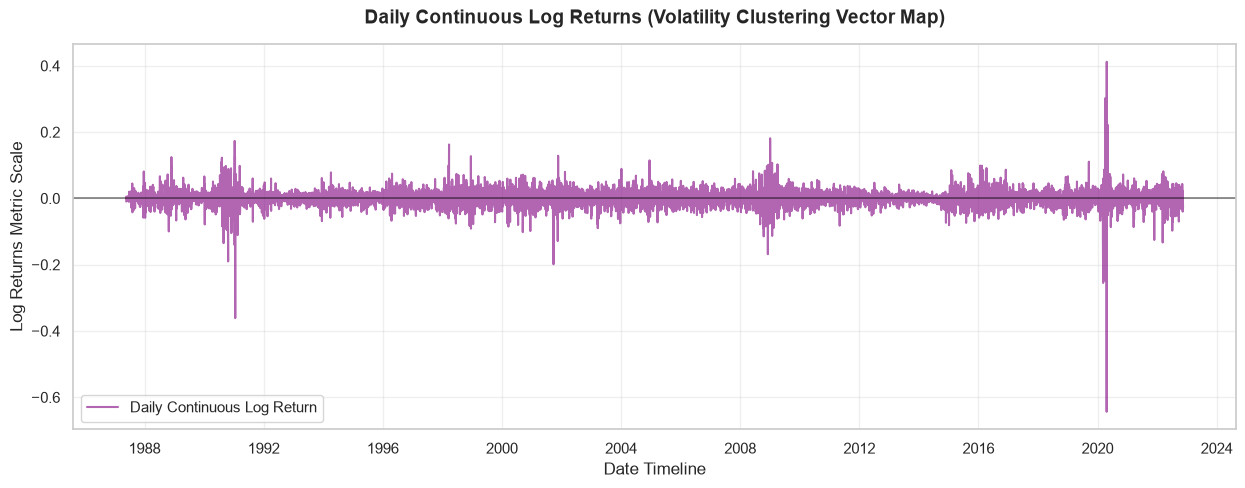

In [6]:
plt.figure(figsize=(15, 5))
plt.plot(df['Date'], df['Log_Return'], color='purple', alpha=0.6, label='Daily Continuous Log Return')
plt.axhline(0, color='black', linestyle='-', alpha=0.5, linewidth=1.2)

plt.title('Daily Continuous Log Returns (Volatility Clustering Vector Map)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Date Timeline', fontsize=12)
plt.ylabel('Log Returns Metric Scale', fontsize=12)
plt.legend(loc='lower left', fontsize=11)
plt.grid(True, alpha=0.3)

# Auto-save into Visuals folder
fig2_path = os.path.join(visuals_dir, "brent_log_returns_clustering.png")
plt.savefig(fig2_path, dpi=300, bbox_inches='tight')
print(f"Saved Figure 2 to: {fig2_path}")
plt.show()

## 4. Run Mathematical Stationarity Verifications

In [7]:
print("Testing Absolute Raw Prices Stationarity Status:")
execute_adf_diagnostic(df, target_col='Price')

print("\nTesting Processed Log Returns Stationarity Status:")
execute_adf_diagnostic(df, target_col='Log_Return')

2026-07-12 00:50:48,014 - INFO - Running Augmented Dickey-Fuller (ADF) test on column: Price


Testing Absolute Raw Prices Stationarity Status:


2026-07-12 00:50:49,119 - INFO - Running Augmented Dickey-Fuller (ADF) test on column: Log_Return



 AUGMENTED DICKEY-FULLER DIAGNOSTICS FOR 'Price'
ADF Test Statistic : -1.993856
Empirical p-value  : 2.8927e-01
Stationary Status  : FAIL (Non-Stationary)
Critical 5% Value  : -2.8619


Testing Processed Log Returns Stationarity Status:

 AUGMENTED DICKEY-FULLER DIAGNOSTICS FOR 'Log_Return'
ADF Test Statistic : -16.427113
Empirical p-value  : 2.4986e-29
Stationary Status  : PASS (Is Stationary)
Critical 5% Value  : -2.8619



{'Test_Statistic': np.float64(-16.427113494485752),
 'p_value': np.float64(2.498580161143622e-29),
 'Used_Lags': 28,
 'Observations': 8981,
 'Critical_Values': {'1%': np.float64(-3.4310783342658615),
  '5%': np.float64(-2.861861876398633),
  '10%': np.float64(-2.566941329781918)},
 'Stationary': np.True_}

## 5. Tail Risk Outlier Distributions

In [8]:
outliers = df[df['Is_Outlier'] == 1]
print(f"Total tracked historical 3-sigma outliers: {len(outliers)}")
display(outliers[['Date', 'Price', 'Log_Return']].tail(10))

Total tracked historical 3-sigma outliers: 99


,Date,Price,Log_Return
8361,2020-04-23,15.06,0.089550
8365,2020-04-29,17.86,0.135293
8368,2020-05-04,20.40,0.098305
8369,2020-05-05,25.46,0.221574
8394,2020-06-11,37.76,-0.086702
8591,2021-03-18,62.11,-0.086622
8767,2021-11-26,72.37,-0.125537
8838,2022-03-09,116.58,-0.133124
8844,2022-03-17,113.50,0.081564
8918,2022-07-05,110.49,-0.097455
